In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from utils.formatting import calculate_scale
from variables import COMPANY, PERIOD_LABELS, COLORS, COLOR_RATINGS

In [28]:
def style_spines(ax=None, linewidth=0.75, alpha=0.5):
    if ax is None:
        ax = plt.gca()

    for spine in ax.spines.values():
        spine.set_linewidth(linewidth)
        spine.set_alpha(alpha)

In [29]:
try:
    short_name = COMPANY.info["shortName"]
    three_colors = [color for color in COLORS.values()]

except Exception as e:
    print(f"Error while fetching company short name / colors: {e}")
    short_name = ""
    three_colors = []

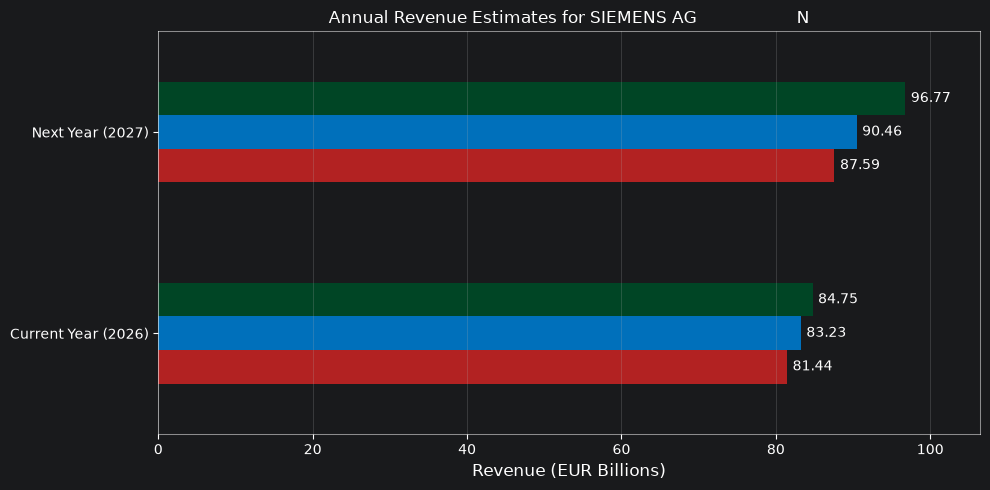

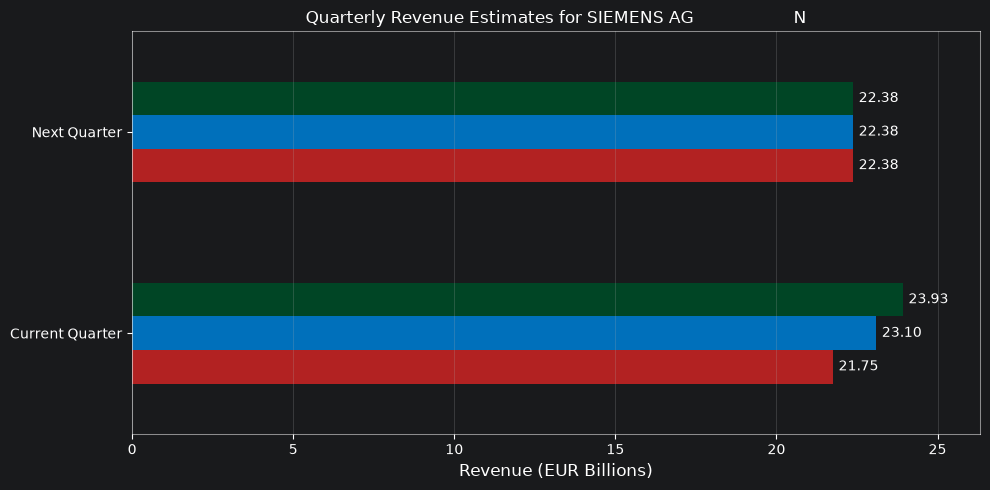

In [30]:
try:
    def plot_revenue_estimates(revenue, title):
        scale, unit = calculate_scale(revenue[["low", "avg", "high"]].max().max())

        ax = (revenue.set_index("period")[["low", "avg", "high"]] / scale).plot(kind="barh", figsize=(10, 5),
                                                                                color=three_colors, legend=False)

        for container in ax.containers:
            labels = [f"{value:.2f}" for value in container.datavalues]
            ax.bar_label(container, labels=labels, padding=4)

        plt.title(f"{title} Revenue Estimates for {short_name}", fontsize=12)
        plt.xlabel(f"Revenue ({currency} {unit})", fontsize=12)
        plt.ylabel("")
        plt.yticks(rotation=0)
        plt.grid(axis="x", alpha=0.3)
        ax.margins(x=0.1)

        style_spines(ax=ax)

        plt.tight_layout()
        plt.show()


    revenue = COMPANY.get_revenue_estimate().reset_index()
    currency = revenue["currency"].iloc[0]

    revenue["period"] = revenue["period"].map(PERIOD_LABELS).fillna(revenue.period)

    annual = revenue[revenue.period.str.contains("Year")]
    plot_revenue_estimates(annual, "Annual")

    quarterly = revenue[revenue.period.str.contains("Quarter")]
    plot_revenue_estimates(quarterly, "Quarterly")

except Exception as e:
    print(f"Error while fetching/plotting revenue estimates: {e}")

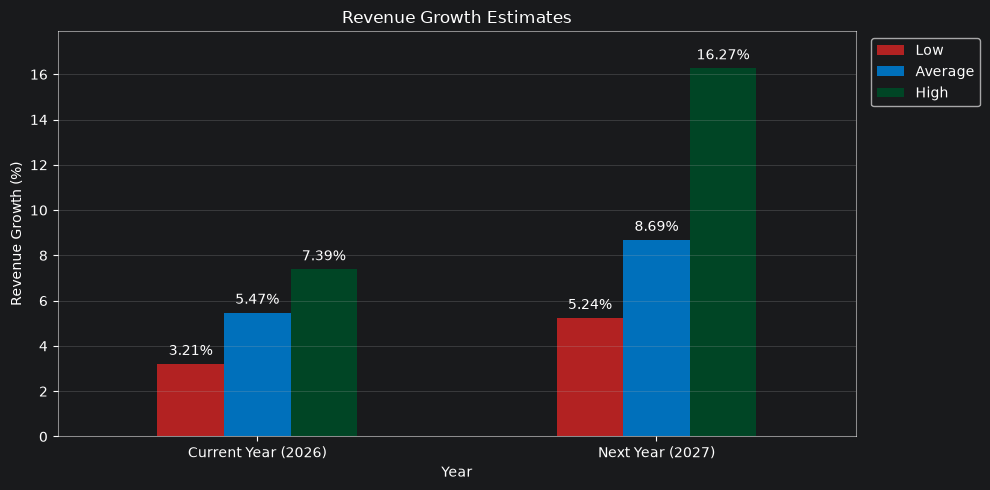

In [31]:
try:
    revenue = COMPANY.get_revenue_estimate().reset_index().set_index("period")
    base_year = COMPANY.income_stmt.loc["Total Revenue"].iloc[0]

    revenue_growth = []
    for period in ["0y", "+1y"]:
        base = (base_year if period == "0y" else revenue.loc["0y", "avg"])
        estimate = revenue.loc[period]

        revenue_growth.append({
            "Year": PERIOD_LABELS[period],
            "Low": round((estimate["low"] / base - 1) * 100, 2),
            "Average": round((estimate["avg"] / base - 1) * 100, 2),
            "High": round((estimate["high"] / base - 1) * 100, 2)
        })

    revenue_growth = pd.DataFrame(revenue_growth)

    ax = revenue_growth.set_index("Year")[["Low", "Average", "High"]].plot(kind="bar", figsize=(10, 5),
                                                                           color=three_colors)

    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f%%", padding=4)

    plt.ylabel("Revenue Growth (%)")
    plt.title("Revenue Growth Estimates")

    plt.xticks(rotation=0)
    plt.grid(axis="y", alpha=0.3)

    ax.margins(y=0.1)

    plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left")

    style_spines(ax=ax)

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Error while calculating/plotting revenue growth estimates: {e}")
    revenue_growth = pd.DataFrame()

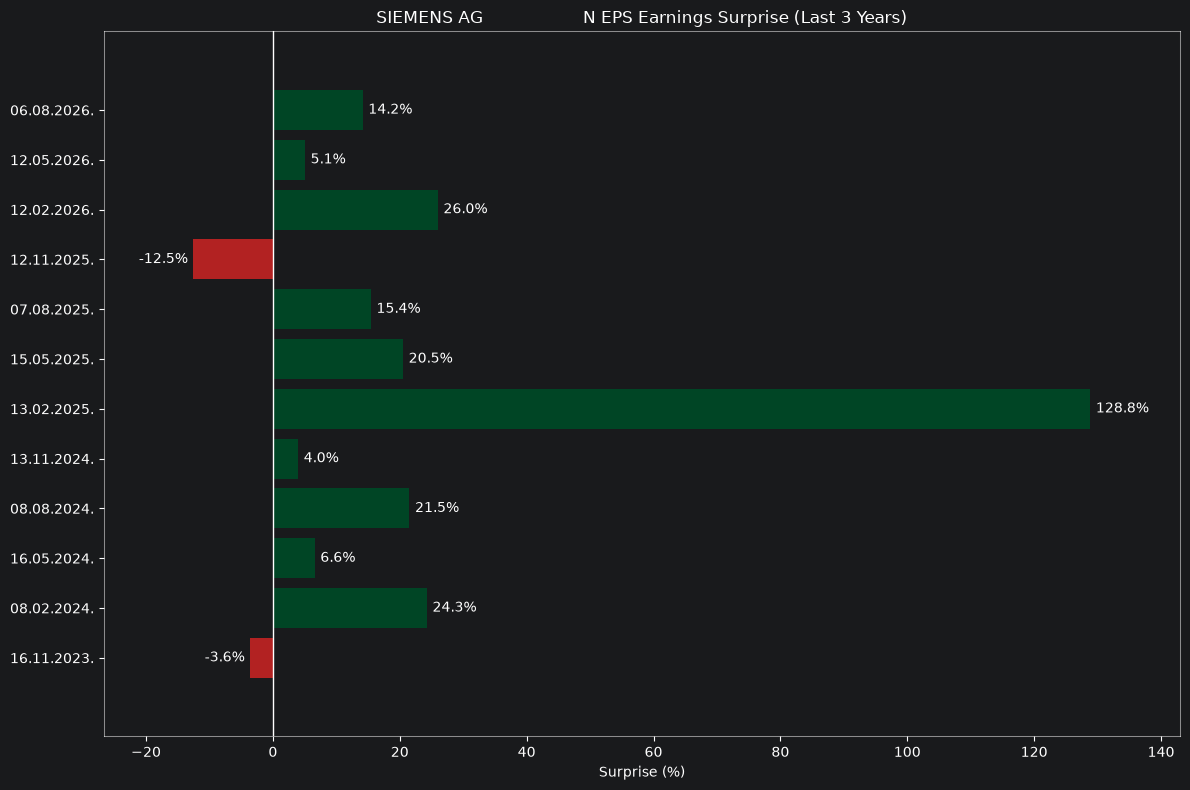

In [32]:
try:
    earnings = COMPANY.get_earnings_dates(limit=50).reset_index()
    earnings = earnings.dropna(subset=["Surprise(%)"])

    today = pd.Timestamp.today(tz=earnings["Earnings Date"].dt.tz).normalize()
    cutoff = today - pd.DateOffset(years=3)

    earnings = earnings[earnings["Earnings Date"] >= cutoff]

    earnings["Date"] = earnings["Earnings Date"].dt.strftime("%d.%m.%Y.")
    earnings = earnings.sort_values("Earnings Date")

    fig, ax = plt.subplots(figsize=(12, 8))

    bars = ax.barh(earnings.Date, earnings["Surprise(%)"], color=[COLORS["green"] if surprise >= 0 else COLORS["red"]
                                                                  for surprise in earnings["Surprise(%)"]])
    ax.bar_label(bars, labels=[f"{value:.1f}%" for value in earnings["Surprise(%)"]], padding=4)

    ax.axvline(0, color="white", lw=1)

    ax.margins(x=0.1, y=0.1)

    ax.set_title(f"{short_name} EPS Earnings Surprise (Last 3 Years)")
    ax.set_xlabel("Surprise (%)")
    ax.set_ylabel("")

    style_spines(ax=ax)

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Error while fetching/plotting earnings surprise history: {e}")

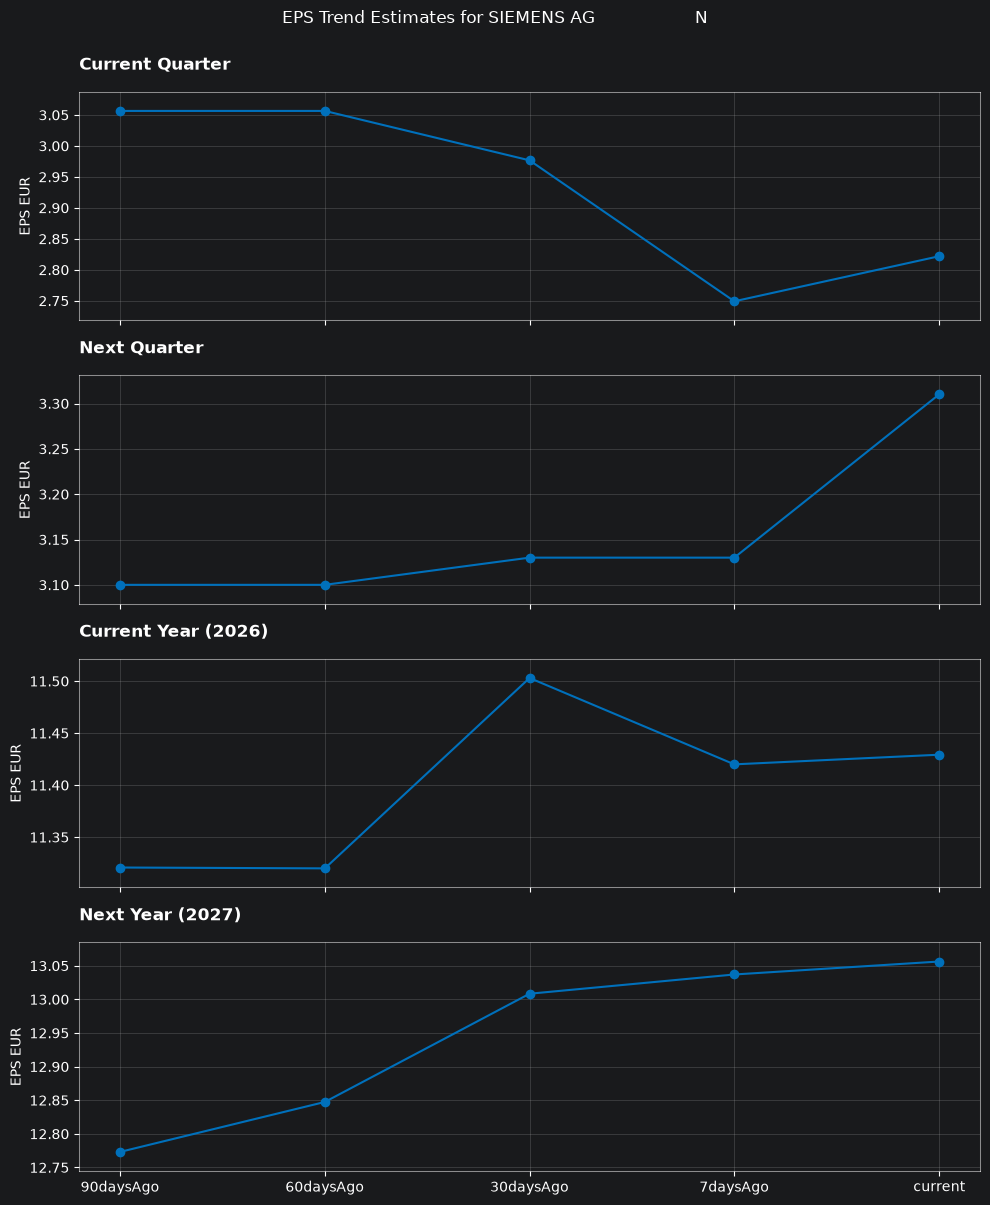

In [33]:
try:
    eps_trend = COMPANY.get_eps_trend().reset_index()
    currency = eps_trend["currency"].iloc[0]

    eps_trend["period"] = eps_trend["period"].map(PERIOD_LABELS).fillna(eps_trend.period)
    time_columns = ["90daysAgo", "60daysAgo", "30daysAgo", "7daysAgo", "current"]

    fig, axes = plt.subplots(len(eps_trend), 1, figsize=(10, 3 * len(eps_trend)), sharex=True, squeeze=False)

    axes = axes.flatten()

    for ax, (_, row) in zip(axes, eps_trend.iterrows()):
        y = pd.to_numeric(row[time_columns], errors="coerce")

        ax.plot(time_columns, y, marker="o", color=COLORS["blue"])
        ax.set_title(row.get("period", "-"), fontsize=12, fontweight="bold", loc="left", pad=16)
        ax.set_ylabel(f"EPS {currency}")
        ax.grid(True, alpha=0.3)
        ax.margins(y=0.1)

        style_spines(ax=ax)

    fig.suptitle(f"EPS Trend Estimates for {short_name}", fontsize=12, y=1.0)

    plt.tight_layout()
    plt.show()

    pct_change = (eps_trend[time_columns].pct_change(axis=1) * 100).iloc[:, 1:].map(lambda number: f"{number:.2f}%")
    pct_change = pd.concat([eps_trend.period, pct_change], axis=1)

except Exception as e:
    print(f"Error while fetching/plotting EPS trend estimates: {e}")
    pct_change = pd.DataFrame()

In [34]:
pct_change

,period,60daysAgo,30daysAgo,7daysAgo,current
0,Current Quarter,0.00%,-2.61%,-7.64%,2.65%
1,Next Quarter,0.00%,0.97%,0.00%,5.75%
2,Current Year (2026),-0.01%,1.62%,-0.72%,0.08%
3,Next Year (2027),0.58%,1.25%,0.22%,0.15%


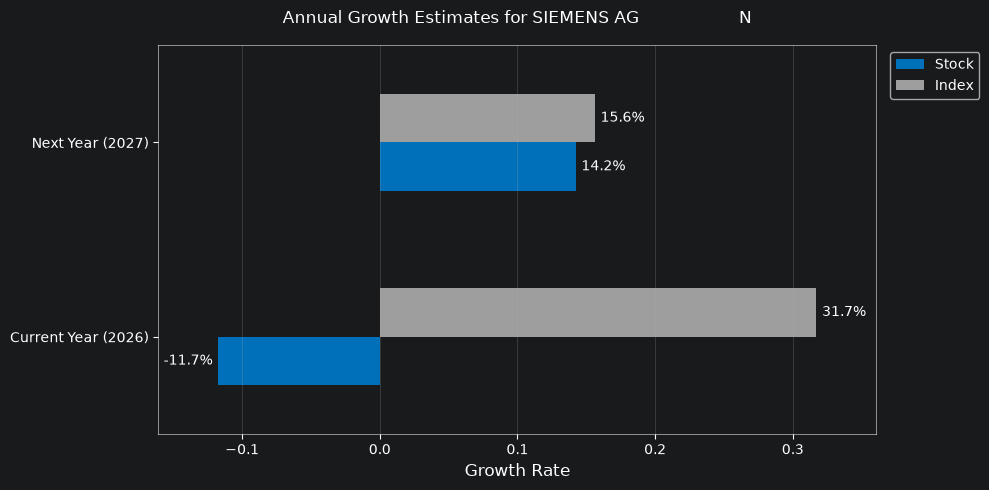

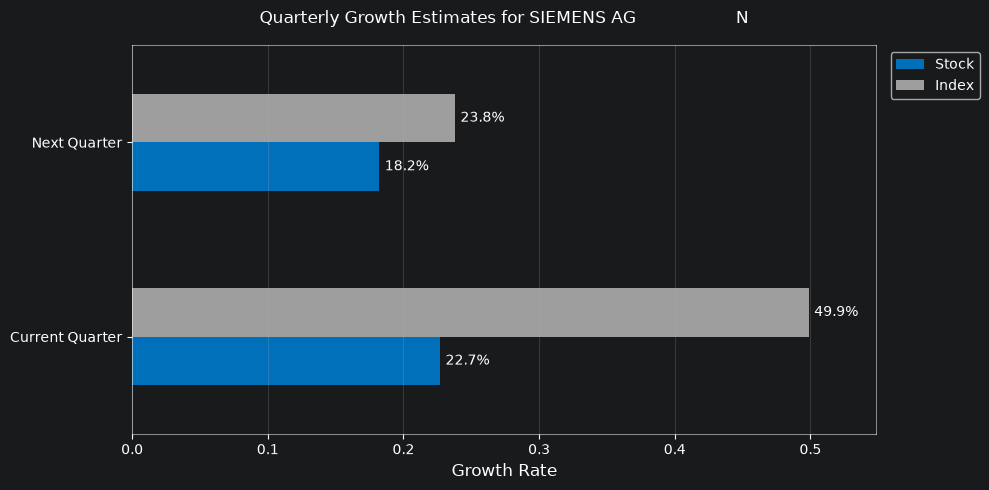

In [35]:
try:
    growth_est = COMPANY.get_growth_estimates().reset_index()
    growth_est = growth_est[growth_est["period"] != "LTG"]

    growth_est["period"] = growth_est.period.map(PERIOD_LABELS).fillna(growth_est.period)


    def plot_growth_estimates(growth_est, title):
        ax = growth_est.set_index("period")[["stockTrend", "indexTrend"]].plot(kind="barh", figsize=(10, 5),
                                                                               color=[COLORS["blue"], COLORS["gray"]],
                                                                               legend=False)

        ax.legend(["Stock", "Index"], bbox_to_anchor=(1.01, 1), loc="upper left")

        for container in ax.containers:
            ax.bar_label(container, labels=[f"{value:.1%}" for value in container.datavalues], padding=4)

        plt.title(f"{title} Growth Estimates for {short_name}", fontsize=12, pad=16)
        plt.xlabel("Growth Rate", fontsize=12)
        plt.ylabel("")
        plt.grid(axis="x", alpha=0.3)
        ax.margins(x=0.1)

        style_spines(ax=ax)

        plt.tight_layout()
        plt.show()


    annual = growth_est[growth_est.period.str.contains("Year")]
    plot_growth_estimates(annual, "Annual")

    quarter = growth_est[growth_est.period.str.contains("Quarter")]
    plot_growth_estimates(quarter, "Quarterly")

except Exception as e:
    print(f"Error while fetching/plotting growth estimates: {e}")

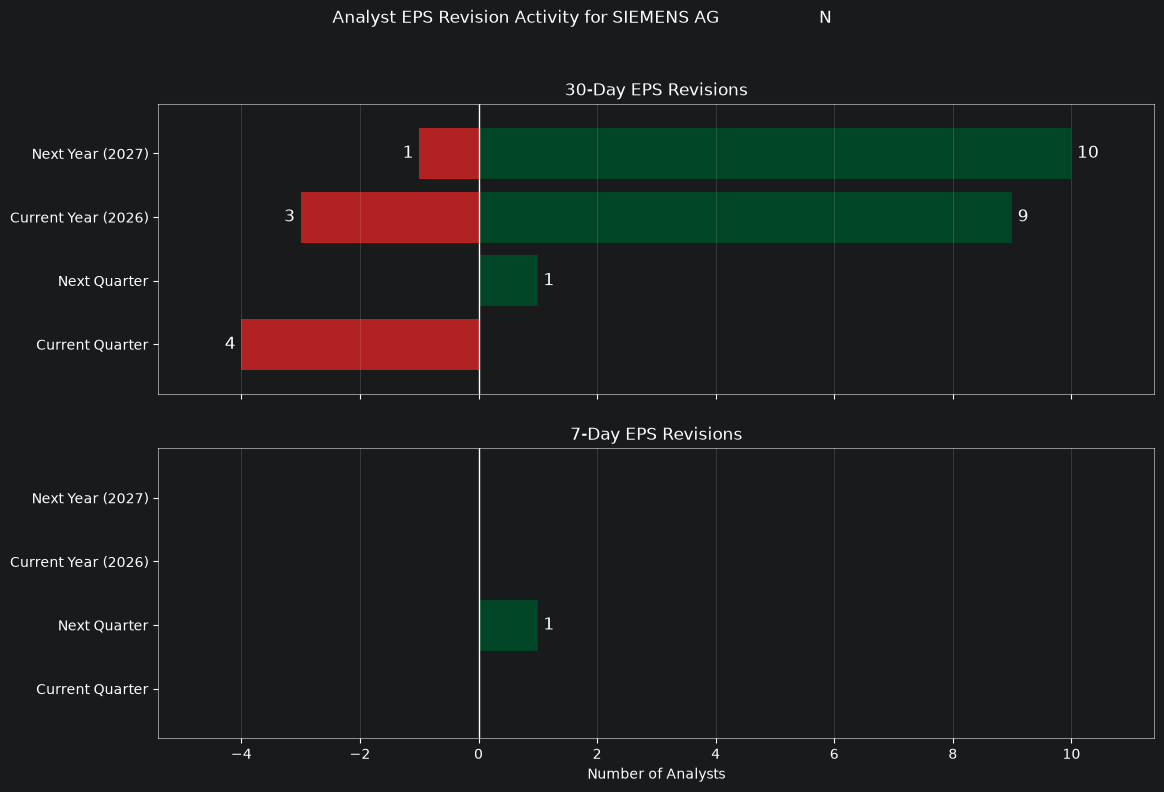

In [36]:
try:
    eps_rev = COMPANY.get_eps_revisions().reset_index()
    eps_rev["period"] = eps_rev["period"].map(PERIOD_LABELS).fillna(eps_rev.period)


    def set_labels(series):
        return [f"{value:.0f}" if value else "" for value in series]


    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    up30 = ax1.barh(eps_rev.period, eps_rev["upLast30days"], label="Up", color=COLORS["green"])
    down30 = ax1.barh(eps_rev.period, -eps_rev["downLast30days"], label="Down", color=COLORS["red"])
    ax1.axvline(0, color="white", lw=1)
    ax1.set_title("30-Day EPS Revisions")

    ax1.bar_label(up30, labels=set_labels(eps_rev.upLast30days), padding=4, fontsize=12)
    ax1.bar_label(down30, labels=set_labels(eps_rev.downLast30days), padding=4, fontsize=12)

    up7 = ax2.barh(eps_rev.period, eps_rev["upLast7days"], color=COLORS["green"])
    down7 = ax2.barh(eps_rev.period, -eps_rev["downLast7Days"], color=COLORS["red"])
    ax2.axvline(0, color="white", lw=1)
    ax2.set_title("7-Day EPS Revisions")
    ax2.set_xlabel("Number of Analysts")

    ax2.bar_label(up7, labels=set_labels(eps_rev.upLast7days), padding=4, fontsize=12)
    ax2.bar_label(down7, labels=set_labels(eps_rev.downLast7Days), padding=4, fontsize=12)

    for ax in (ax1, ax2):
        ax.margins(x=0.1, y=0.1)
        ax.grid(axis="x", alpha=0.3)
        style_spines(ax=ax)

    fig.suptitle(f"Analyst EPS Revision Activity for {short_name}", fontsize=12, y=1.0)

    plt.tight_layout(pad=2)
    plt.show()

except Exception as e:
    print(f"Error while fetching/plotting EPS revision activity: {e}")

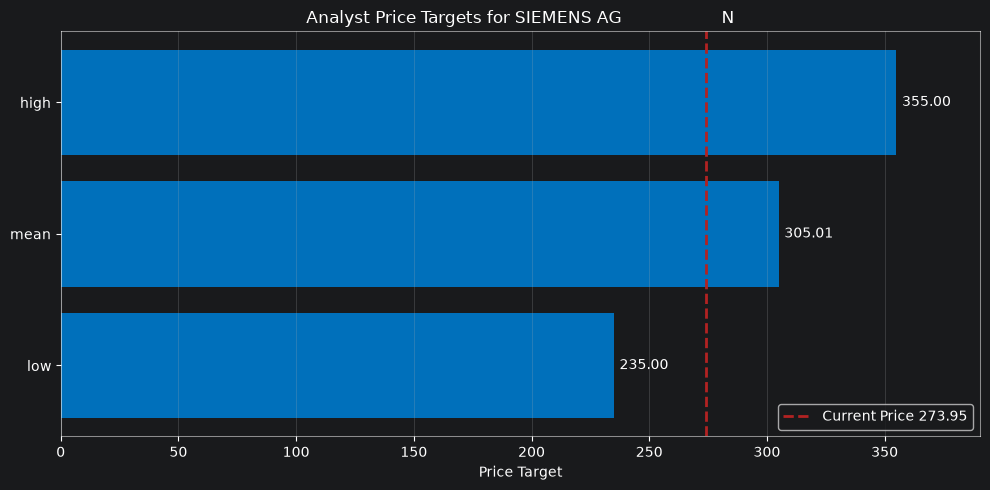

Low Target Upside: -14.22%
Mean Target Upside: 11.34%
High Target Upside: 29.59%


In [37]:
try:
    targets = COMPANY.get_analyst_price_targets()

    targets = pd.DataFrame(list(targets.items()), columns=["Target", "Price"])
    current_price = targets.loc[targets["Target"] == "current", "Price"].values[0]

    targets = targets[~targets.Target.isin(["current", "median"])]
    targets = targets.sort_values("Price")

    plt.figure(figsize=(10, 5))

    bars = plt.barh(targets.Target, targets["Price"], color=COLORS["blue"])

    plt.bar_label(bars, fmt="%.2f", padding=4)

    plt.axvline(current_price, color=COLORS["red"], linestyle="--", linewidth=2,
                label=f"Current Price {current_price:.2f}")

    plt.xlabel("Price Target")
    plt.title(f"Analyst Price Targets for {short_name}")
    plt.legend()

    plt.margins(x=0.1)
    plt.grid(axis="x", alpha=0.3)

    style_spines()

    plt.tight_layout()
    plt.show()

    for label in ["low", "mean", "high"]:
        price = targets.loc[targets.Target == label, "Price"].values[0]
        upside = (price - current_price) / current_price * 100
        print(f"{label.capitalize()} Target Upside: {upside:.2f}%")

except Exception as e:
    print(f"Error while fetching/plotting analyst price targets: {e}")

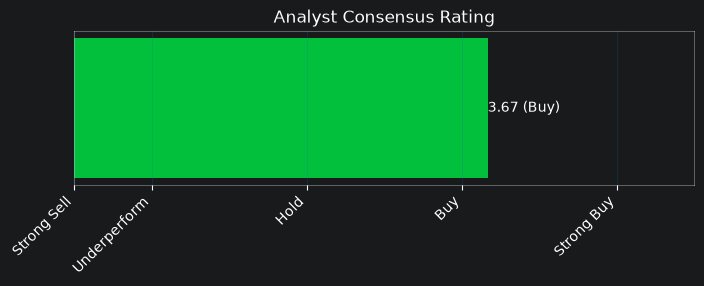

In [38]:
try:
    rating = COMPANY.get_recommendations().iloc[0]

    weights = {
        "strongBuy": 5,
        "buy": 4,
        "hold": 3,
        "underperform": 2,
        "strongSell": 1
    }

    total_score = 0
    total_analysts = 0

    for key, weight in weights.items():
        value = int(rating.get(key, 0))
        total_score += value * weight
        total_analysts += value

    score = total_score / total_analysts
    ratings = [(4.5, "Strong Buy"), (3.5, "Buy"), (2.5, "Hold"), (1.5, "Underperform")]

    analyst_rating = "Strong Sell"
    for threshold, label in ratings:
        if score >= threshold:
            analyst_rating = label
            break

    plt.figure(figsize=(8, 2))

    plt.barh(["Analyst Rating"], [score], color=COLOR_RATINGS[analyst_rating])
    plt.yticks([])

    plt.xlim(1, 5)

    plt.text(score, 0, f"{score:.2f} ({analyst_rating})", va="center", ha="left")

    plt.xticks([1, 1.5, 2.5, 3.5, 4.5], ["Strong Sell", "Underperform", "Hold", "Buy", "Strong Buy"], rotation=45,
               ha="right")

    plt.title("Analyst Consensus Rating")
    plt.grid(axis="x", alpha=0.3, color=COLORS["blue"])

    style_spines(alpha=0.3)

    plt.show()

except Exception as e:
    print(f"Error while calculating/plotting analyst consensus rating: {e}")
    score = None
    analyst_rating = None

In [39]:
try:
    upgrades_downgrades = COMPANY.get_upgrades_downgrades()
    delta = datetime.now() - timedelta(days=365)

    upgrades_downgrades = upgrades_downgrades[upgrades_downgrades.index >= delta]

    up_down = upgrades_downgrades[upgrades_downgrades["Action"].isin(["up", "down"])]
    counts = up_down["Action"].value_counts()

    plt.figure(figsize=(6, 4))
    bars = plt.bar(
        ["Upgrades", "Downgrades"],
        [counts.get("up", 0), counts.get("down", 0)],
        color=[COLORS["green"], COLORS["red"]]
    )
    plt.bar_label(bars)
    plt.ylim(0, counts.max() * 1.1)
    plt.ylabel("Number of Analyst Actions")
    plt.title("Analyst Upgrades vs Downgrades (Last 365 Days)")
    plt.grid(axis="y", alpha=0.3)
    style_spines()
    plt.show()

    price_targets = upgrades_downgrades[upgrades_downgrades["priceTargetAction"].isin(["Raises", "Lowers"])]
    counts = price_targets["priceTargetAction"].value_counts()

    plt.figure(figsize=(6, 4))
    bars = plt.bar(
        ["Raises", "Lowers"],
        [counts.get("Raises", 0), counts.get("Lowers", 0)],
        color=[COLORS["green"], COLORS["red"]]
    )
    plt.bar_label(bars)
    plt.ylim(0, counts.max() * 1.1)
    plt.ylabel("Number of Price Target Changes")
    plt.title("Analyst Price Target Changes (Last 365 Days)")
    plt.grid(axis="y", alpha=0.3)
    style_spines()
    plt.show()

    price_targets["Change %"] = (
            (price_targets["currentPriceTarget"] - price_targets["priorPriceTarget"])
            / price_targets.priorPriceTarget
            * 100
    )

    stats = price_targets.groupby("priceTargetAction")["Change %"].agg(["min", "max", "mean"])

    print(f"Average Raise: {stats.loc["Raises", "mean"]:.2f}%")
    print(f"Average Lower: {stats.loc["Lowers", "mean"]:.2f}%")
    print(f"Average Change: {price_targets["Change %"].mean():.2f}%")
    print(f"\nLargest Raise: {stats.loc["Raises", "max"]:.2f}%")
    print(f"Largest Lower: {stats.loc["Lowers", "min"]:.2f}%")

except Exception as e:
    print(f"Error while fetching/plotting upgrades and downgrades: {e}")

Error while fetching/plotting upgrades and downgrades: 'Action'
